In [2]:
#File: Final Project

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# Load data
def load_cluster_data(filename, cluster_name):
    print(f"--- Loading {cluster_name} ---")
    
    # Load file
    try:
        df = pd.read_csv(filename, sep=';', comment='#', dtype=str)
    except FileNotFound:
        print(f"Could not find {filename}.")
        return None

    # Find data columns automatically
    cols = df.columns
    v_col = next((c for c in cols if 'Vmag' in c), None)
    bv_col = next((c for c in cols if 'B-V' in c), None)
    plx_col = next((c for c in cols if 'Plx' in c), None)

    if not v_col or not bv_col:
        print(f"Could not find Vmag or B-V columns in {filename}.")
        print(f"Columns found: {cols.tolist()}")
        return None

    # 3. Create a DataFrame and convert to numbers
    clean_df = pd.DataFrame()
    
    clean_df['V_mag'] = pd.to_numeric(df[v_col], errors='coerce')
    clean_df['B_V'] = pd.to_numeric(df[bv_col], errors='coerce')
    
    if plx_col:
        clean_df['Parallax_mas'] = pd.to_numeric(df[plx_col], errors='coerce')
        
        # Filter/clean numbers
        clean_df = clean_df.dropna(subset=['Parallax_mas'])
        clean_df = clean_df[clean_df['Parallax_mas'] > 0]
        
        clean_df['Distance_pc'] = 1000 / clean_df['Parallax_mas']
    else:
        print("No Parallax column found. Using default distance.")
        # Default distance if parallax is not found
        if 'Pleiades' in cluster_name:
            clean_df['Distance_pc'] = 136.2
        elif 'M67' in cluster_name:
            clean_df['Distance_pc'] = 850
        else:
            clean_df['Distance_pc'] = 100 

    clean_df['Cluster'] = cluster_name
    
    # Drop rows that did not convert (NaNs)
    clean_df = clean_df.dropna()
    
    return clean_df

--- Loading Pleiades ---
Successfully loaded 98 stars for Pleiades.


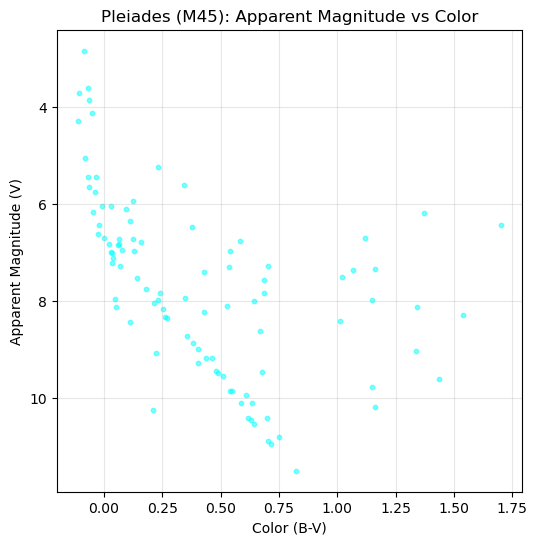

In [5]:
# Load Pleiades (M45)
pleiades = load_cluster_data('Pleiades.tsv', 'Pleiades')

if pleiades is not None:
    print(f"Successfully loaded {len(pleiades)} stars for Pleiades.")
    
    # Plot
    plt.figure(figsize=(6,6))
    plt.scatter(pleiades['B_V'], pleiades['V_mag'], s=10, alpha=0.5, color='cyan')
    plt.gca().invert_yaxis()
    plt.title("Pleiades (M45): Apparent Magnitude vs Color")
    plt.xlabel("Color (B-V)")
    plt.ylabel("Apparent Magnitude (V)")
    plt.grid(True, alpha=0.3)
    plt.show()

--- Loading M67 ---
Successfully loaded 60 stars for M67.


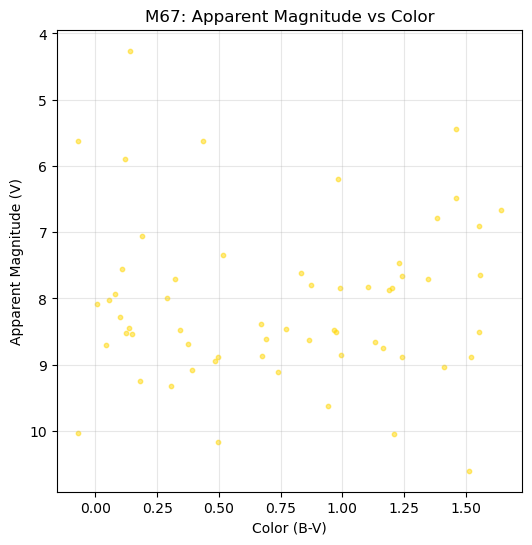

In [6]:
# Load M67
M67 = load_cluster_data('M67.tsv', 'M67')

if M67 is not None:
    print(f"Successfully loaded {len(M67)} stars for M67.")
    
    # Plot
    plt.figure(figsize=(6,6))
    plt.scatter(M67['B_V'], M67['V_mag'], s=10, alpha=0.5, color='gold')
    plt.gca().invert_yaxis()
    plt.title("M67: Apparent Magnitude vs Color")
    plt.xlabel("Color (B-V)")
    plt.ylabel("Apparent Magnitude (V)")
    plt.grid(True, alpha=0.3)
    plt.show()

--- Processing Pleiades ---
   Found columns: V='Vmag
mag', B-V='B-V
mag'
Loaded 98 stars.
--- Processing M67 ---
   Found columns: V='Vmag
mag', B-V='B-V
mag'
Loaded 62 stars.

[1] Saved 'key_plot_hr_diagram.png'


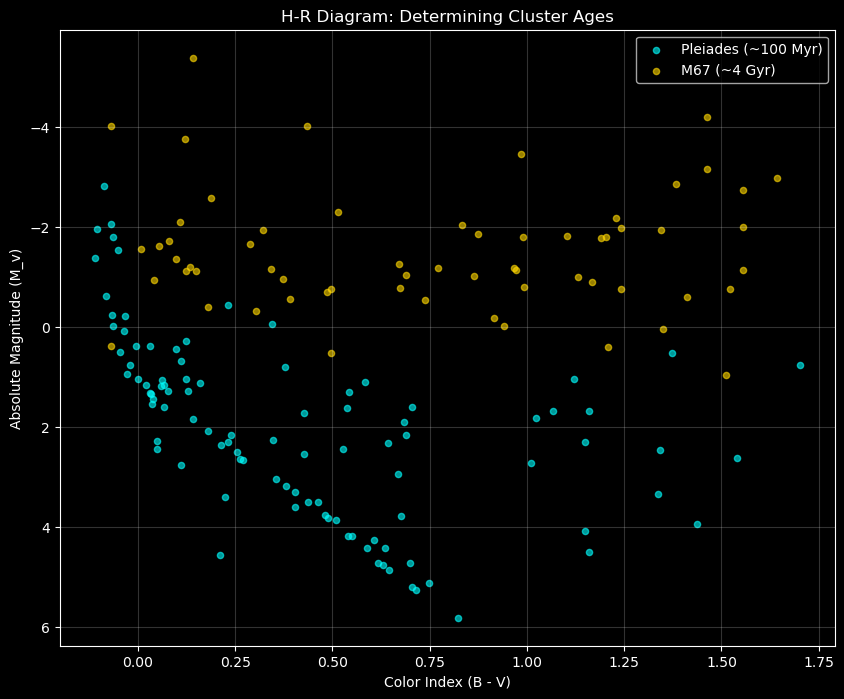

[2] Saved 'supporting_plot_turnoff.png'


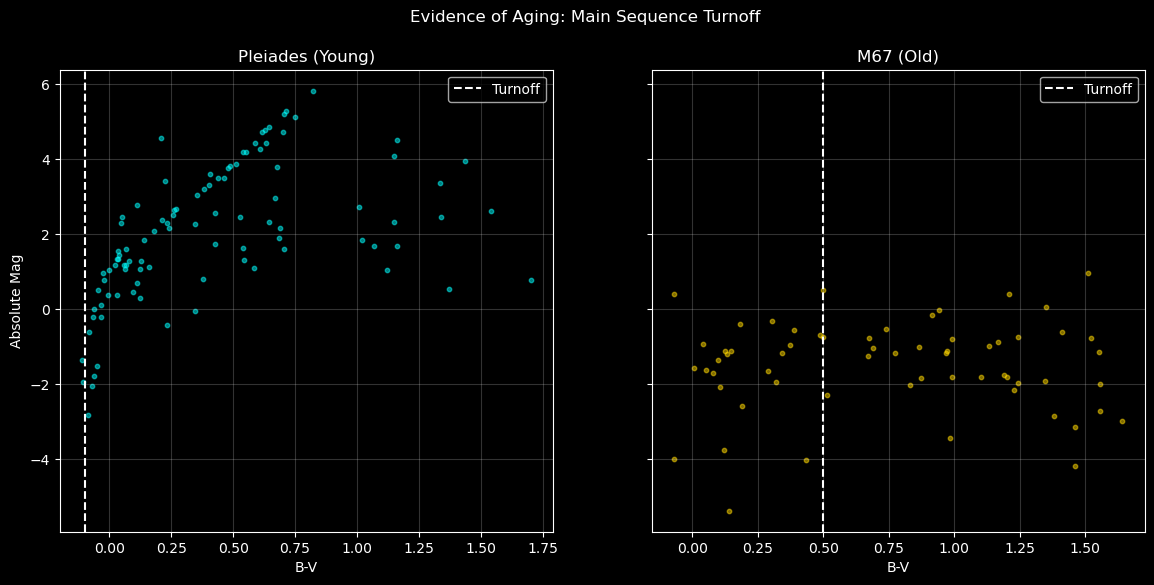

In [8]:
plt.style.use('dark_background') 

def load_cluster_data(filename, cluster_name, distance_pc):
    print(f"--- Processing {cluster_name} ---")
    
    try:
        df = pd.read_csv(filename, dtype=str)
    except FileNotFoundError:
        print(f"Could not find '{filename}'")
        return None

    # Find columns
    cols = df.columns
    
    # "Vmag"
    v_col = next((c for c in cols if 'Vmag' in str(c)), None)
    # "B-V"
    bv_col = next((c for c in cols if 'B-V' in str(c)), None)

    if not v_col or not bv_col:
        print(f"   Error: Could not find Vmag or B-V in {filename}.")
        print(f"   Columns found: {cols.tolist()}")
        return None

    print(f"   Found columns: V='{v_col}', B-V='{bv_col}'")

    # Clean
    clean_df = pd.DataFrame()
    clean_df['V_mag'] = pd.to_numeric(df[v_col], errors='coerce')
    clean_df['B_V'] = pd.to_numeric(df[bv_col], errors='coerce')
    clean_df = clean_df.dropna()
    
    # Absolute Magnitude: M = V - 5 * log10(d) + 5
    clean_df['M_v'] = clean_df['V_mag'] - 5 * np.log10(distance_pc) + 5
    clean_df['Cluster'] = cluster_name
    
    print(f"Loaded {len(clean_df)} stars.")
    return clean_df

pleiades = load_cluster_data('pleiades.csv', 'Pleiades', 136.2)
m67 = load_cluster_data('m67.csv', 'M67', 850)


if pleiades is not None and m67 is not None:
    all_data = pd.concat([pleiades, m67])
    
    # Key plot
    plt.figure(figsize=(10, 8))
    
    # Pleiades
    p_data = all_data[all_data['Cluster'] == 'Pleiades']
    plt.scatter(p_data['B_V'], p_data['M_v'], s=20, c='cyan', alpha=0.6, label='Pleiades (~100 Myr)')
    
    # M67
    m_data = all_data[all_data['Cluster'] == 'M67']
    plt.scatter(m_data['B_V'], m_data['M_v'], s=20, c='gold', alpha=0.6, label='M67 (~4 Gyr)')
    
    plt.gca().invert_yaxis() # Bright stars are at the top 
    plt.xlabel('Color Index (B - V)')
    plt.ylabel('Absolute Magnitude (M_v)')
    plt.title('H-R Diagram: Determining Cluster Ages')
    plt.legend()
    plt.grid(True, alpha=0.2)
    
    plt.savefig('key_plot_hr_diagram.png')
    print("\n[1] Saved 'key_plot_hr_diagram.png'")
    plt.show()

    # Turnoff Points
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    
    # Pleiades
    ax1.scatter(p_data['B_V'], p_data['M_v'], s=10, c='cyan', alpha=0.5)
    ax1.set_title("Pleiades (Young)")
    ax1.set_xlabel("B-V")
    ax1.set_ylabel("Absolute Mag")
    ax1.invert_yaxis()
    ax1.grid(True, alpha=0.2)
    ax1.axvline(-0.1, color='white', linestyle='--', label='Turnoff')
    ax1.legend()
    
    # M67
    ax2.scatter(m_data['B_V'], m_data['M_v'], s=10, c='gold', alpha=0.5)
    ax2.set_title("M67 (Old)")
    ax2.set_xlabel("B-V")
    ax2.invert_yaxis()
    ax2.grid(True, alpha=0.2)
    ax2.axvline(0.5, color='white', linestyle='--', label='Turnoff')
    ax2.legend()
    
    plt.suptitle("Evidence of Aging: Main Sequence Turnoff")
    plt.savefig('supporting_plot_turnoff.png')
    print("[2] Saved 'supporting_plot_turnoff.png'")
    plt.show()

else:
    print("Could not run analysis. Please check file names.")